<a href="https://colab.research.google.com/github/Nav-del/Machine-Learning-Course/blob/main/K_MeansClustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
%matplotlib inline
from copy import deepcopy
import numpy as np
import pandas as pd
import seaborn as sns
sns.set() #used for styling
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = (15, 5)
plt.style.use('ggplot')

#importing the dataset
data = pd.read_csv('movie_metadata.csv')
print(data.shape)
print(data.head())

(5043, 28)
   color      director_name  num_critic_for_reviews  duration  \
0  Color      James Cameron                   723.0     178.0   
1  Color     Gore Verbinski                   302.0     169.0   
2  Color         Sam Mendes                   602.0     148.0   
3  Color  Christopher Nolan                   813.0     164.0   
4    NaN        Doug Walker                     NaN       NaN   

   director_facebook_likes  actor_3_facebook_likes      actor_2_name  \
0                      0.0                   855.0  Joel David Moore   
1                    563.0                  1000.0     Orlando Bloom   
2                      0.0                   161.0      Rory Kinnear   
3                  22000.0                 23000.0    Christian Bale   
4                    131.0                     NaN        Rob Walker   

   actor_1_facebook_likes        gross                           genres  ...  \
0                  1000.0  760505847.0  Action|Adventure|Fantasy|Sci-Fi  ...   
1    

In [3]:
data['director_facebook_likes']

,director_facebook_likes
0,0.0
1,563.0
2,0.0
3,22000.0
4,131.0
...,...
5038,2.0
5039,NaN
5040,0.0
5041,0.0


In [8]:
newdata = data.iloc[:,4:6]
newdata = newdata.fillna(newdata.mean()) #fill missing values with mean of the dataset
newdata

,director_facebook_likes,actor_3_facebook_likes
0,0.000000,855.000000
1,563.000000,1000.000000
2,0.000000,161.000000
3,22000.000000,23000.000000
4,131.000000,645.009761
...,...,...
5038,2.000000,318.000000
5039,686.509212,319.000000
5040,0.000000,0.000000
5041,0.000000,489.000000


In [9]:
#Using K Means
from sklearn.cluster import KMeans

In [10]:
kmeans = KMeans(n_clusters=5)
kmeans.fit(newdata)

KMeans(n_clusters=5)

In [12]:
kmeans.cluster_centers_

array([[  165.17883939,   423.54434021],
       [17544.11764706,   598.77941176],
       [  210.77011494, 11126.43678161],
       [12441.17647059,   604.34313725],
       [17545.45454545, 14545.45454545]])

In [13]:
print(kmeans.labels_)
print(len(kmeans.labels_))

[0 0 0 ... 0 0 0]
5043


In [14]:
print(type(kmeans.labels_))
unique, counts = np.unique(kmeans.labels_, return_counts=True)
print(dict(zip(unique, counts)))

<class 'numpy.ndarray'>
{np.int32(0): np.int64(4775), np.int32(1): np.int64(68), np.int32(2): np.int64(87), np.int32(3): np.int64(102), np.int32(4): np.int64(11)}


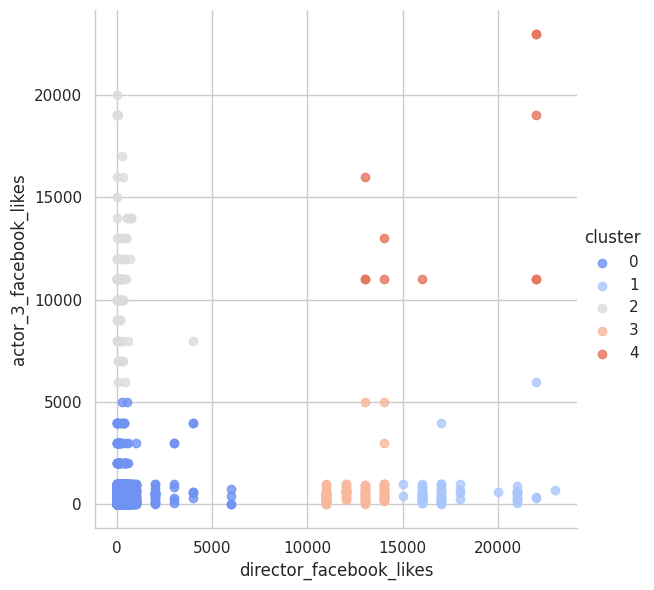

In [16]:
#Plotting the data
newdata['cluster'] = kmeans.labels_
sns.set_style('whitegrid')
sns.lmplot(x='director_facebook_likes',y='actor_3_facebook_likes',data=newdata, hue='cluster',palette='coolwarm',height=6, aspect=1,fit_reg=False)
plt.show()